## Tail exponent for coloured noise and $N \rightarrow \infty$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import random_growth_src.lib as lib

plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

## Figure 3)

In [2]:
def D_tilde_crit_approx(lamb_tilde):
    
    return  1 / (2 - (lamb_tilde / (lamb_tilde + 1)))

In [3]:
lamb_tildes = np.logspace(-1.5, 2.3, 200)
D_tildes =  np.logspace(-0.6, 0.2, 200)
exponents = np.zeros((len(D_tildes), len(lamb_tildes)))
for i, D_tilde in enumerate(D_tildes):
    for j ,lamb_tilde in enumerate(lamb_tildes):
        exponents[i, j] = 1/D_tilde + lib.solve_zeta(1, D_tilde, lamb_tilde) / D_tilde 

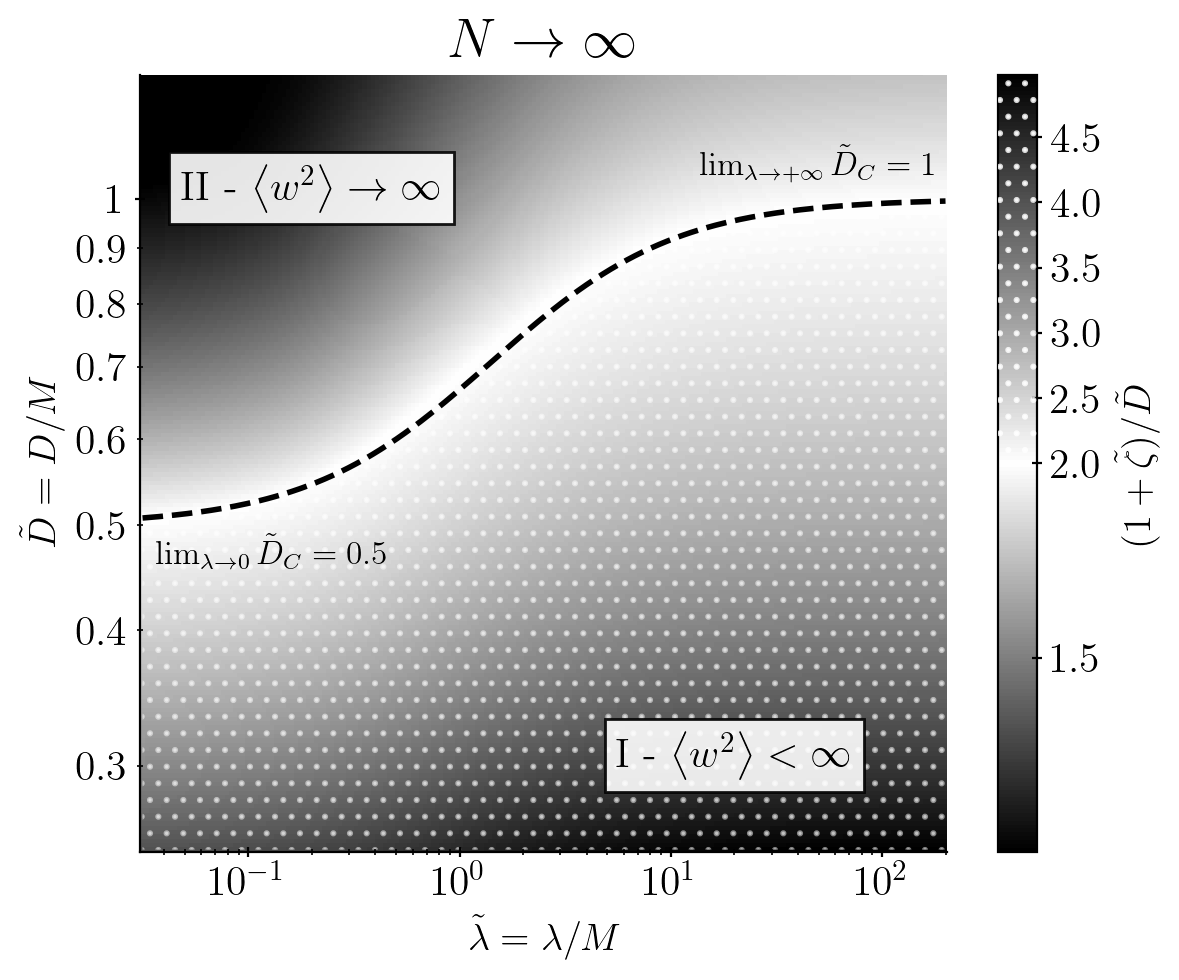

In [ ]:
bw_div = LinearSegmentedColormap.from_list("bw_div", ["black", "white", "black"], N=200) 
norm = colors.TwoSlopeNorm(vmin=np.nanmin(exponents), vcenter=2.0, vmax=np.nanmax(exponents))

fig, ax = plt.subplots(figsize=(6, 5), tight_layout='true')

X, Y = np.meshgrid(lamb_tildes, D_tildes)
density = ax.pcolormesh(X, Y, exponents, cmap=bw_div, norm=norm, shading="auto", rasterized=True)

ax.plot(lamb_tildes, D_tilde_crit_approx(lamb_tildes), linestyle='--', linewidth=2, c='black')
ax.fill_between(lamb_tildes, np.min(D_tildes), D_tilde_crit_approx(lamb_tildes), hatch='..', facecolor='none', edgecolor='white', linewidth=0, alpha=0.5)

ax.set_ylim([None, 1.3])
ax.loglog()
cbar = fig.colorbar(density, ax=ax)
cbar.set_label(r"$ (1 + \tilde{\zeta}) / \tilde{D}$")
ax.set_xlabel(r"$\tilde{\lambda} = \lambda / M$")
ax.set_ylabel(r"$\tilde{D} = D / M$")

ax.set_xlabel(r"$\tilde{\lambda} = \lambda / M$")
ax.set_ylabel(r"$\tilde{D} = D / M$")
ax.text(0.2, 1, r"II - $\left< w^2\right> \rightarrow \infty$", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9))
ax.text(20, 0.3, r"I - $\left< w^2\right> < \infty$ ", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.9))
ax.text(0.13, 0.46, r"$\lim_{\lambda \rightarrow 0}\tilde{D}_C = 0.5$", fontsize=12, weight='bold', c='black', ha='center')
ax.text(50, 1.05, r"$\lim_{\lambda \rightarrow +\infty}\tilde{D}_C = 1$", fontsize=12, weight='bold', c='black', ha='center')

split = float(norm(2.0))  
r_hi = Rectangle(
    (0, split), 1, 1 - split,
    transform=cbar.ax.transAxes,
    facecolor="none",
    edgecolor="white",
    hatch="..",
    linewidth=0,
    alpha=0.8,
    zorder=10,
)

r_hi.set_clip_path(cbar.outline)
cbar.ax.add_patch(r_hi)

fmt = mticker.FuncFormatter(lambda v, _: f"{v:.1f}".rstrip("0").rstrip("."))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)))
ax.yaxis.set_major_formatter(fmt)
ax.yaxis.set_minor_formatter(fmt)
ax.set_title(r"$N \rightarrow \infty$", fontsize=20)
plt.savefig('../figures/tail_exponent.pdf', bbox_inches='tight', dpi=200, transparent=True);

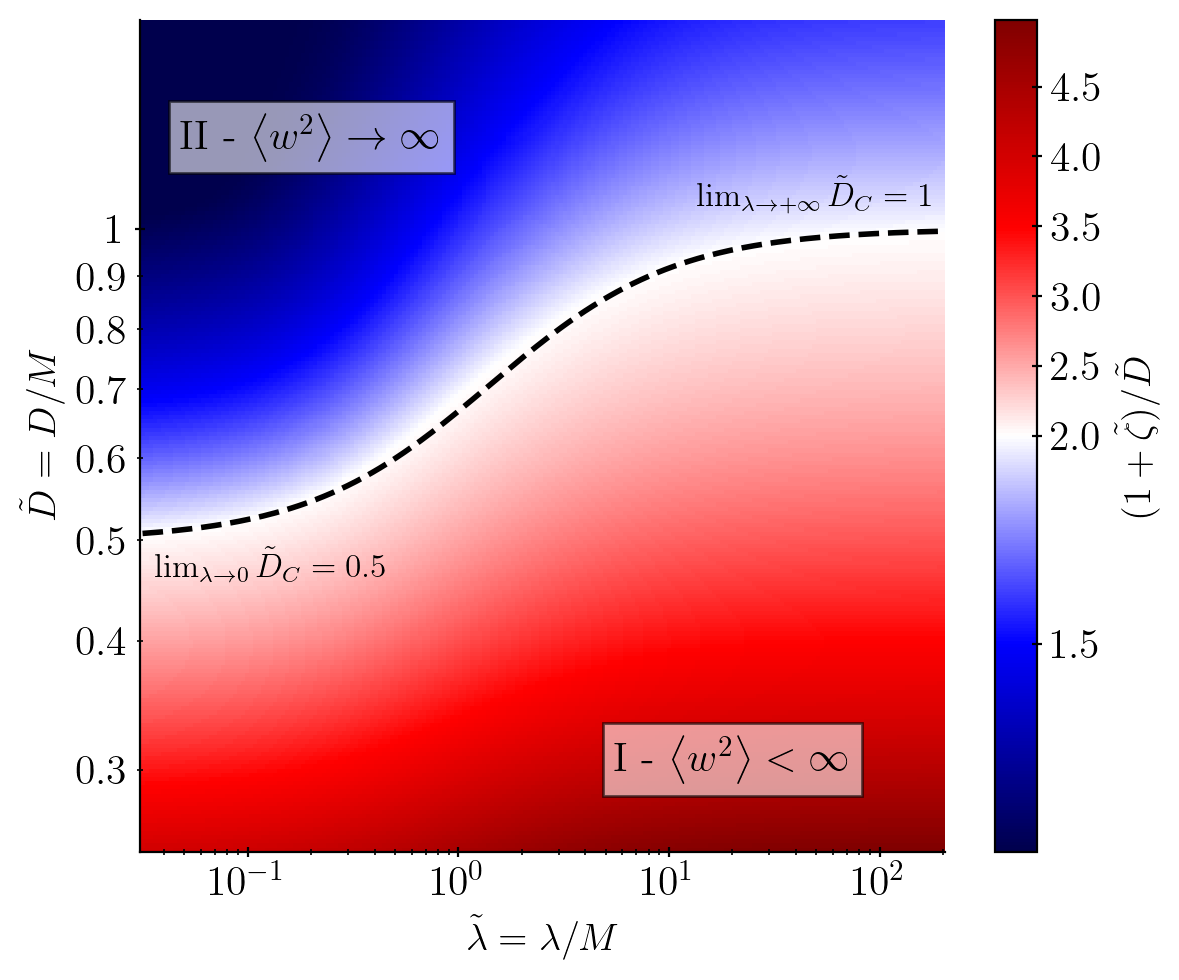

In [ ]:
fig, ax = plt.subplots(figsize =(6, 5), tight_layout='true')

X, Y = np.meshgrid(lamb_tildes, D_tildes)
density = ax.pcolormesh(X, Y, exponents , cmap=sns.color_palette("seismic", as_cmap=True), norm=colors.TwoSlopeNorm(vcenter=2.0),
                         rasterized=True)
ax.plot(lamb_tildes, D_tilde_crit_approx(lamb_tildes), linestyle='--',  linewidth=2, c='black')

ax.loglog()
cbar = fig.colorbar(density, ax=ax)
cbar.set_label(r"$ (1 + \tilde{\zeta}) / \tilde{D}$")
ax.set_xlabel(r"$\tilde{\lambda} = \lambda / M$")
ax.set_ylabel(r"$\tilde{D} = D / M$")
ax.text(0.2, 1.2, r"II - $\left< w^2\right> \rightarrow \infty$", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.6))
ax.text(20, 0.3, r"I - $\left< w^2\right> < \infty$ ", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.6))
ax.text(0.13, 0.46, r"$\lim_{\lambda \rightarrow 0}\tilde{D}_C = 0.5$", fontsize=12, weight='bold', c='black', ha='center')
ax.text(50, 1.05, r"$\lim_{\lambda \rightarrow +\infty}\tilde{D}_C = 1$", fontsize=12, weight='bold', c='black', ha='center')


fmt = mticker.FuncFormatter(lambda v, _: f"{v:.1f}".rstrip("0").rstrip("."))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)))
ax.yaxis.set_major_formatter(fmt)
ax.yaxis.set_minor_formatter(fmt)
plt.savefig('../figures/tail_exponent_color.pdf', bbox_inches='tight', dpi=200, transparent=True);